Employee Attrition Prediction Using Machine Learning
-------------------------------------------------------------
"""
Project Objective
-----------------
Employee attrition is a major concern for organizations because replacing
experienced employees increases recruitment costs, training expenses,
and decreases productivity.

The objective of this project is to:

1. Explore employee data to understand attrition patterns.
2. Clean and preprocess the dataset.
3. Build machine learning models to predict employee attrition.
4. Compare different classification models.
5. Identify the most important factors influencing attrition.
6. Provide actionable HR recommendations based on data-driven insights.
"""

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Set plotting style
sns.set(style="whitegrid")

Task 1 – Data Loading & Exploration
---------
The objective of this task is to:

• Load the HR Attrition dataset.

• Understand the dataset structure.

• Identify the target variable.

• Explore employee attrition.

• Identify numerical and categorical features.


In [2]:
# Load dataset

df = pd.read_csv("HR_Attrition.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# ----------------------------------------------------------
# IMPORTANT
# ----------------------------------------------------------
# eda_df  -> Used ONLY for Exploratory Data Analysis
# model_df -> Used ONLY for Machine Learning
#
# This avoids KeyError after One-Hot Encoding.
# ----------------------------------------------------------

eda_df = df.copy()

model_df = df.copy()

In [4]:
# Display first 10 records

eda_df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
# Number of rows and columns

print("Dataset Shape :", eda_df.shape)

Dataset Shape : (1470, 35)


In [6]:
# Display column names and data types

eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
# Check missing values in each column

eda_df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
# Display target variable

print(eda_df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [9]:
# Percentage of employees who left

attrition_rate = (
    (eda_df["Attrition"]=="Yes").mean()
)*100

print(f"Overall Attrition Rate : {attrition_rate:.2f}%")

Overall Attrition Rate : 16.12%


In [10]:
# Identify numerical columns

numeric_columns = eda_df.select_dtypes(include=np.number).columns

# Identify categorical columns

categorical_columns = eda_df.select_dtypes(include="object").columns

print("Number of Numeric Columns :",len(numeric_columns))

print("Number of Categorical Columns :",len(categorical_columns))

Number of Numeric Columns : 26
Number of Categorical Columns : 9


In [11]:
print(numeric_columns)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [12]:
print(categorical_columns)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')



Summary
-------

• Dataset contains 1470 employee records.

• Dataset contains 35 features.

• Attrition is the target variable.

• Overall attrition rate is approximately 16%.

• Dataset is imbalanced because more employees stayed than left.

• No missing values were found.

• Both numerical and categorical variables are present.


""" Task 2 – Data Cleaning & Preprocessing """
-----------------------------------------------

Objective
---------

Prepare the dataset for machine learning by:

• Removing unnecessary columns

• Encoding categorical variables

• Converting target variable

• Scaling numerical features



In [13]:
# Verify missing values before preprocessing

model_df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [14]:
# These columns do not help prediction

model_df.drop(

    columns=[

        "EmployeeNumber",

        "EmployeeCount",

        "Over18",

        "StandardHours"

    ],

    inplace=True

)

In [15]:
# Convert Yes/No into 1/0

model_df["Attrition"] = model_df["Attrition"].map(

    {

        "Yes":1,

        "No":0

    }

)

In [16]:
model_df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [17]:
categorical_columns = model_df.select_dtypes(

    include="object"

).columns

print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [18]:
# Convert categorical columns into numerical format

model_df = pd.get_dummies(

    model_df,

    columns=categorical_columns,

    drop_first=True

)

In [19]:
model_df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [20]:
#Separate Features & Target
# Features

X = model_df.drop("Attrition",axis=1)

# Target

y = model_df["Attrition"]

In [21]:
#Train-Test Split
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [22]:
#Feature Scaling
# Standardize numerical features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Task 2 Summary
-------

✔ No missing values.

✔ Irrelevant columns removed.

✔ Target converted into numeric values.

✔ Categorical variables encoded.

✔ Dataset standardized.

✔ Data split into training and testing datasets.

✔ Dataset is now ready for machine learning.


Task 3 – Exploratory Data Analysis (EDA)
==========================================================
"""

Objective
---------
The purpose of this task is to explore the employee dataset
to identify patterns, trends, and factors associated with
employee attrition.

This analysis helps HR understand:
1. Which departments lose the most employees.
2. Which job roles have the highest attrition.
3. Whether salary influences attrition.
4. Whether work-life balance impacts employee retention.
5. At what stage employees are more likely to leave.
"""

In [23]:
# ---------------------------------------------------------
# Calculate attrition percentage for each department
# ---------------------------------------------------------

department_attrition = (
    eda_df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

department_attrition

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

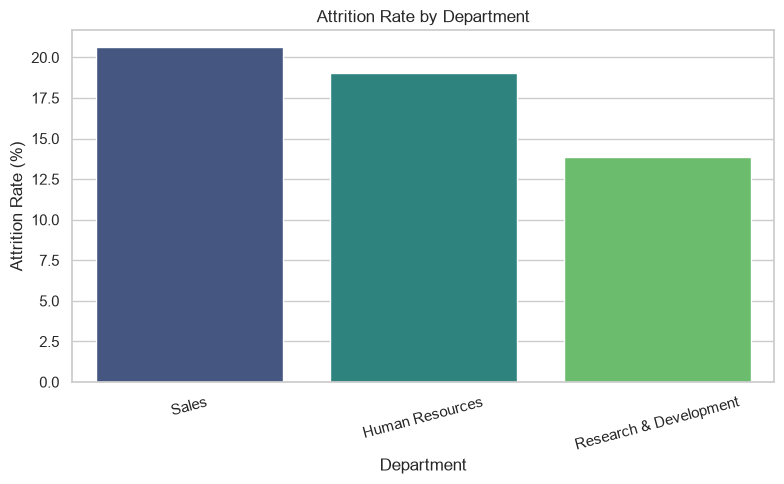

In [91]:
# ---------------------------------------------------------
# Bar Chart - Attrition Rate by Department
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values,
    palette="viridis"
)

plt.title("Attrition Rate by Department")

plt.xlabel("Department")

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig("charts/department_attrition.png")

plt.show()

In [27]:
# ---------------------------------------------------------
# Calculate attrition percentage for each job role
# ---------------------------------------------------------

jobrole_attrition = (
    eda_df.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

jobrole_attrition

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

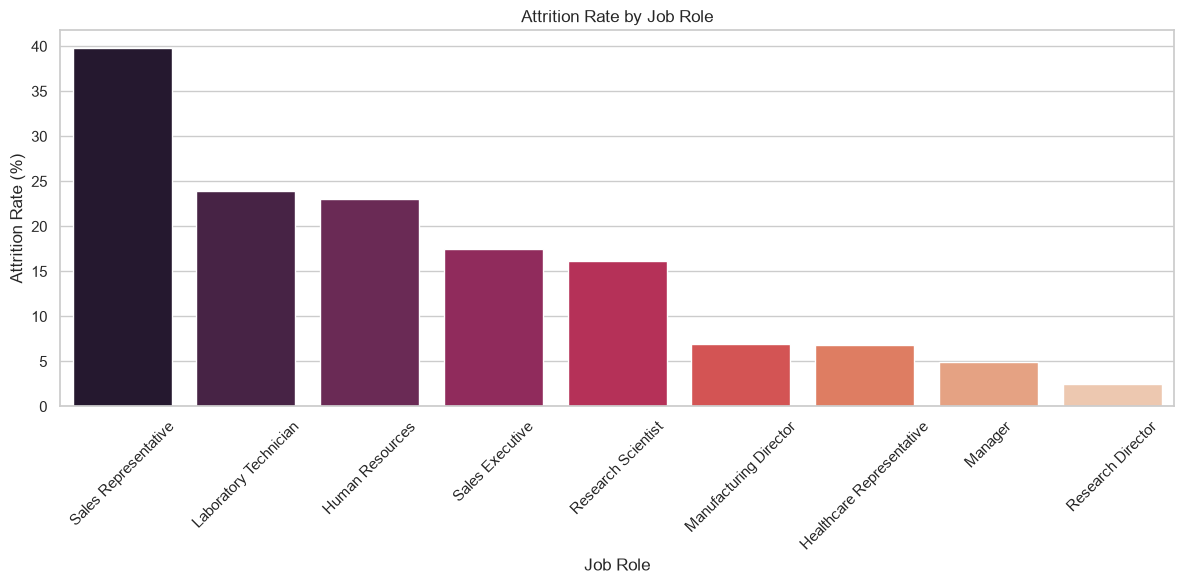

In [ ]:
# show attrition rate for each job role
plt.figure(figsize=(12,6))

sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values,
    palette="rocket"
)

plt.xticks(rotation=45)

plt.title("Attrition Rate by Job Role")

plt.xlabel("Job Role")

plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("charts/jobrole_attrition.png")

plt.show()

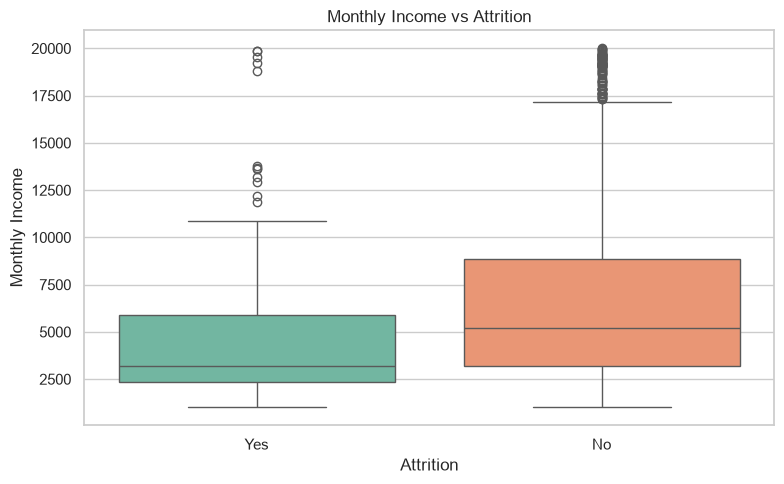

In [89]:
# ---------------------------------------------------------
# Compare salary distribution of employees who stayed
# versus employees who left.
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=eda_df,
    palette="Set2"
)

plt.title("Monthly Income vs Attrition")

plt.xlabel("Attrition")

plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("charts/monthly_income_boxplot.png")

plt.show()

In [30]:
# ---------------------------------------------------------
# Attrition percentage by Work-Life Balance rating
# ---------------------------------------------------------

worklife_attrition = (
    eda_df.groupby("WorkLifeBalance")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

worklife_attrition

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64

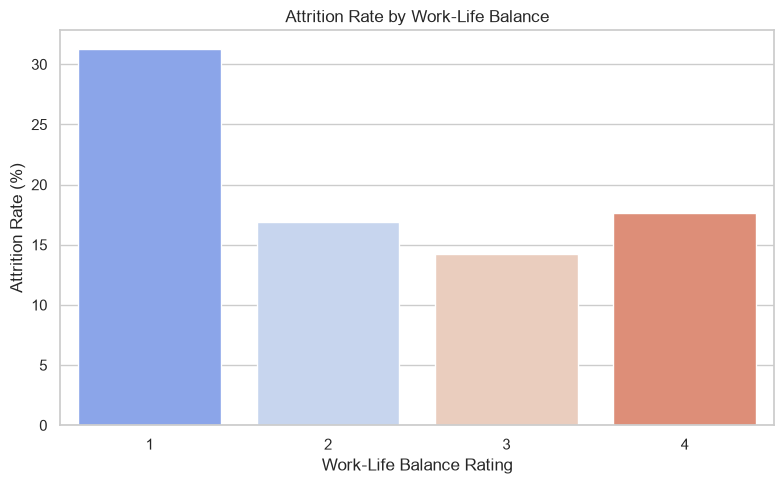

In [88]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=worklife_attrition.index,
    y=worklife_attrition.values,
    palette="coolwarm"
)

plt.title("Attrition Rate by Work-Life Balance")

plt.xlabel("Work-Life Balance Rating")

plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("charts/worklife_balance.png")

plt.show()

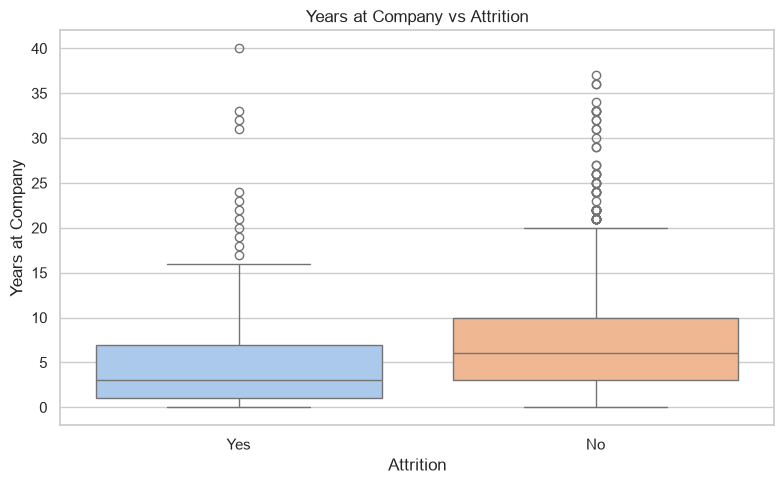

In [87]:
# ---------------------------------------------------------
# Compare employee tenure between employees who stayed
# and employees who left.
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=eda_df,
    palette="pastel"
)

plt.title("Years at Company vs Attrition")

plt.xlabel("Attrition")

plt.ylabel("Years at Company")

plt.tight_layout()

plt.savefig("charts/years_company.png")

plt.show()

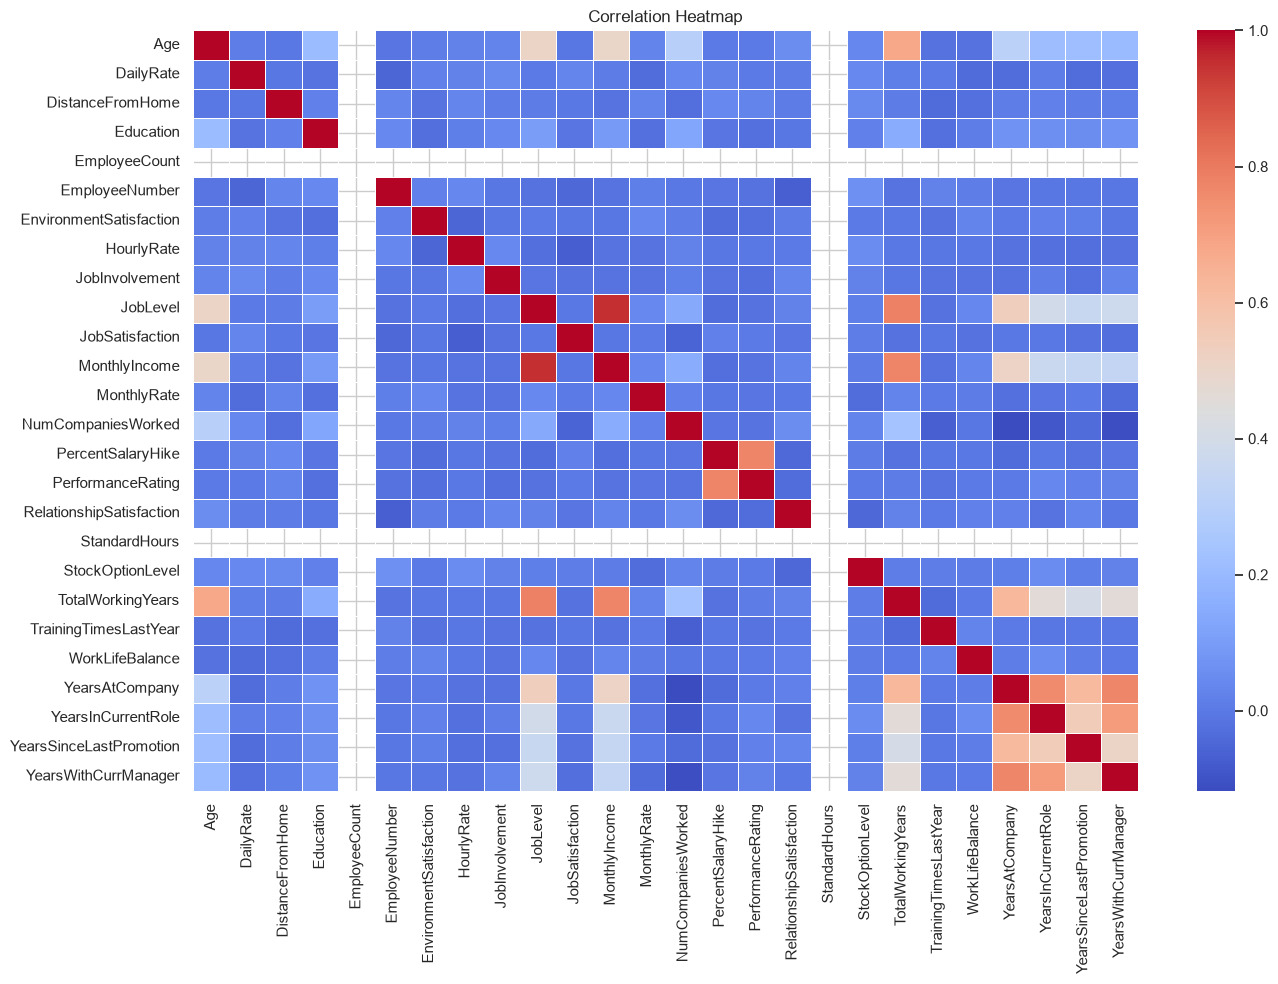

In [33]:
# ---------------------------------------------------------
# Correlation between numerical variables
# ---------------------------------------------------------

plt.figure(figsize=(14,10))

corr = eda_df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

Task 3 Summary
-----------------------------------------------------------
1. Department(s) with the highest attrition should be
   prioritized for retention initiatives.

2. Certain job roles exhibit significantly higher attrition
   than others, suggesting role-specific challenges.

3. Monthly income shows whether salary differences are
   associated with employees leaving, but salary should
   be interpreted alongside other factors.

4. Lower work-life balance ratings may correspond to
   higher attrition, indicating employee well-being
   plays an important role.

5. Employees with shorter tenure may leave more often,
   highlighting the importance of onboarding,
   mentorship, and early career support.

Task 4 – Model Building & Comparison
==========================================================
Objective
---------
The objective of this task is to build multiple machine learning
models that can predict employee attrition.

Three classification models will be trained and compared:

1. Logistic Regression
2. Random Forest Classifier
3. Gradient Boosting Classifier

The performance of each model will be evaluated to identify
the best-performing model for predicting employee attrition.

In [34]:
# ---------------------------------------------------------
# Verify the shape of training and testing datasets
# ---------------------------------------------------------

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1176, 44)
Testing Features  : (294, 44)
Training Labels   : (1176,)
Testing Labels    : (294,)


In [35]:
# ---------------------------------------------------------
# Logistic Regression
# ---------------------------------------------------------
# A simple and interpretable baseline model commonly used
# for binary classification problems.
# ---------------------------------------------------------

lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [36]:
# Predict employee attrition using Logistic Regression

lr_pred = lr_model.predict(X_test)

# Predict probability scores (required for ROC-AUC)

lr_prob = lr_model.predict_proba(X_test)[:,1]

In [37]:
# ---------------------------------------------------------
# Random Forest Classifier
# ---------------------------------------------------------
# An ensemble model that combines multiple decision trees
# to improve prediction accuracy.
# ---------------------------------------------------------

rf_model = RandomForestClassifier(

    random_state=42,

    class_weight="balanced"

)

rf_model.fit(X_train,y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [38]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [39]:
# ---------------------------------------------------------
# Gradient Boosting Classifier
# ---------------------------------------------------------
# Sequentially builds decision trees where each tree
# corrects the mistakes of the previous one.
# ---------------------------------------------------------

gb_model = GradientBoostingClassifier(

    random_state=42

)

gb_model.fit(X_train,y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [40]:
gb_pred = gb_model.predict(X_test)

gb_prob = gb_model.predict_proba(X_test)[:,1]

In [41]:
# ---------------------------------------------------------
# Function to calculate evaluation metrics
# ---------------------------------------------------------

def evaluate_model(model_name, y_true, predictions, probabilities):

    accuracy = accuracy_score(y_true, predictions)

    precision = precision_score(y_true, predictions)

    recall = recall_score(y_true, predictions)

    f1 = f1_score(y_true, predictions)

    roc = roc_auc_score(y_true, probabilities)

    return [

        model_name,

        accuracy,

        precision,

        recall,

        f1,

        roc

    ]

In [42]:
comparison_results = pd.DataFrame(

    [

        evaluate_model(
            "Logistic Regression",
            y_test,
            lr_pred,
            lr_prob
        ),

        evaluate_model(
            "Random Forest",
            y_test,
            rf_pred,
            rf_prob
        ),

        evaluate_model(
            "Gradient Boosting",
            y_test,
            gb_pred,
            gb_prob
        )

    ],

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC"

    ]

)

In [43]:
comparison_results.sort_values(

    by="ROC-AUC",

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.751701,0.345238,0.617021,0.442748,0.798260
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.794384
1,Random Forest,0.836735,0.484848,0.340426,0.400000,0.775390


In [44]:
best_model = comparison_results.sort_values(

    by="ROC-AUC",

    ascending=False

).iloc[0]

print(best_model)

Model        Logistic Regression
Accuracy                0.751701
Precision               0.345238
Recall                  0.617021
F1 Score                0.442748
ROC-AUC                  0.79826
Name: 0, dtype: object



Summary
----------------------------------------
Three machine learning classification models were developed
to predict employee attrition.

The models compared include:

• Logistic Regression
• Random Forest
• Gradient Boosting

Each model was evaluated using Accuracy, Precision,
Recall, F1-Score, and ROC-AUC.

The model with the highest ROC-AUC score will be selected
for detailed evaluation and feature importance analysis
in the next task.



Task 5: Model Evaluation
---------
The purpose of this task is to evaluate the performance of
each machine learning model using various classification
metrics and identify the best-performing model.

The evaluation metrics include:

1. Precision
2. Recall
3. F1 Score
4. ROC-AUC Score
5. Confusion Matrix

Finally, the most important features influencing employee
attrition will be identified using Feature Importance.


In [45]:
# ---------------------------------------------------------
# Logistic Regression Evaluation
# ---------------------------------------------------------

print("="*60)
print("Logistic Regression")
print("="*60)

print(classification_report(y_test, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [46]:
# ---------------------------------------------------------
# Random Forest Evaluation
# ---------------------------------------------------------

print("="*60)
print("Random Forest")
print("="*60)

print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       247
           1       0.48      0.34      0.40        47

    accuracy                           0.84       294
   macro avg       0.68      0.64      0.65       294
weighted avg       0.82      0.84      0.82       294



In [47]:
# ---------------------------------------------------------
# Gradient Boosting Evaluation
# ---------------------------------------------------------

print("="*60)
print("Gradient Boosting")
print("="*60)

print(classification_report(y_test, gb_pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [48]:
# ---------------------------------------------------------
# Display model comparison table
# ---------------------------------------------------------

comparison_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.751701,0.345238,0.617021,0.442748,0.798260
1,Random Forest,0.836735,0.484848,0.340426,0.400000,0.775390
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.794384


In [49]:
# ---------------------------------------------------------
# Select the model with the highest ROC-AUC score
# ---------------------------------------------------------

best_model_name = comparison_results.sort_values(
    by="ROC-AUC",
    ascending=False
).iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


In [50]:
# ---------------------------------------------------------
# Automatically select the predictions based on the best model
# ---------------------------------------------------------

if best_model_name == "Logistic Regression":
    best_predictions = lr_pred
    best_classifier = lr_model

elif best_model_name == "Random Forest":
    best_predictions = rf_pred
    best_classifier = rf_model

else:
    best_predictions = gb_pred
    best_classifier = gb_model

In [51]:
# ---------------------------------------------------------
# Compute Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(
    y_test,
    best_predictions
)

cm

array([[192,  55],
       [ 18,  29]])

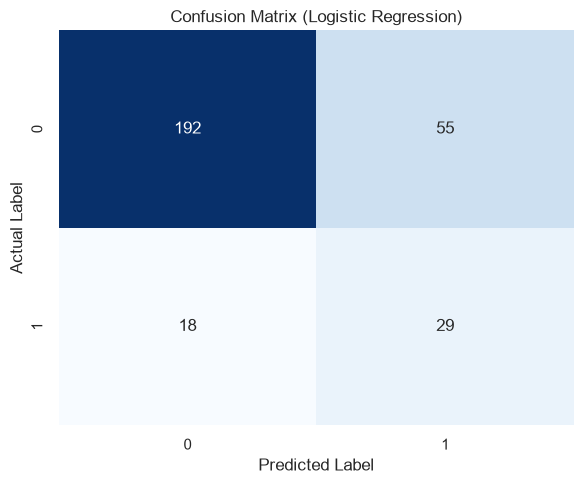

In [86]:
# ---------------------------------------------------------
# Plot Confusion Matrix Heatmap
# ---------------------------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(f"Confusion Matrix ({best_model_name})")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "charts/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 800x600 with 0 Axes>

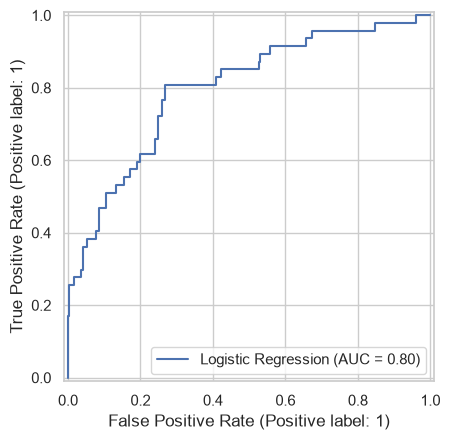

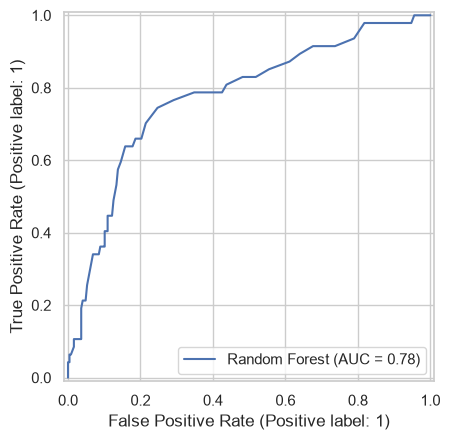

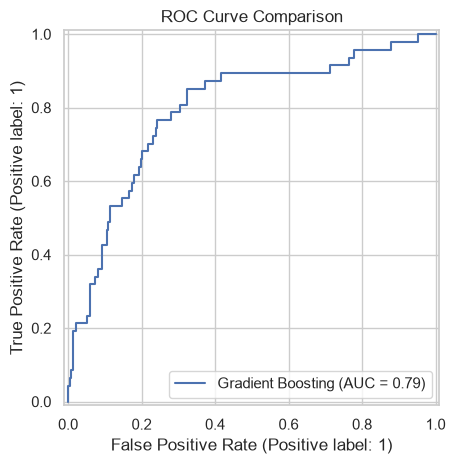

In [85]:
# ---------------------------------------------------------
# Compare ROC Curves of all models
# ---------------------------------------------------------

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    gb_prob,
    name="Gradient Boosting"
)

plt.title("ROC Curve Comparison")

plt.tight_layout()

plt.savefig(
    "charts/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
# ---------------------------------------------------------
# Display feature importance only if the best model
# supports it.
# ---------------------------------------------------------

if hasattr(best_classifier, "feature_importances_"):

    feature_importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_classifier.feature_importances_

    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    feature_importance.head(10)

else:

    print("Feature Importance is not available for Logistic Regression.")

Feature Importance is not available for Logistic Regression.


In [62]:
# ---------------------------------------------------------
# Top 10 Important Features (Logistic Regression)
# ---------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(best_classifier.coef_[0])   # Absolute coefficient values
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 10 Features
feature_importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.810172
43,OverTime_Yes,0.771095
23,BusinessTravel_Travel_Frequently,0.722538
16,TotalWorkingYears,0.660270
7,JobLevel,0.650173
40,JobRole_Sales Representative,0.531090
24,BusinessTravel_Travel_Rarely,0.512780
27,EducationField_Life Sciences,0.512319
21,YearsSinceLastPromotion,0.499063
26,Department_Sales,0.470587


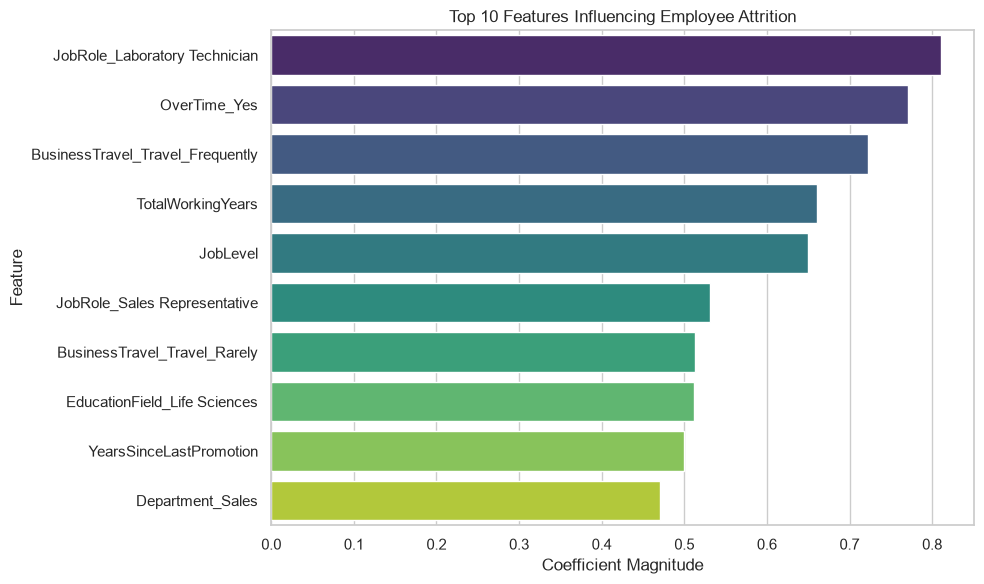

In [64]:
# ---------------------------------------------------------
# Horizontal Bar Chart - Top 10 Important Features
# ---------------------------------------------------------

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Features Influencing Employee Attrition")

plt.xlabel("Coefficient Magnitude")

plt.ylabel("Feature")

plt.tight_layout()


plt.show()

 Summary
------------------------------------------
Three machine learning models were evaluated using
classification metrics including Precision, Recall,
F1-Score, and ROC-AUC.

The model with the highest ROC-AUC score was selected
as the best-performing model.

The confusion matrix was analyzed to understand
prediction performance.

Feature importance analysis identified the top variables
that influence employee attrition, providing valuable
insights for HR decision-making.



Task 6: Visualization
----------------------------------
Objective
---------
The objective of this task is to present key findings using
clear and professional visualizations.

These charts help HR stakeholders quickly understand:
• Attrition patterns
• Salary impact
• Model performance
• Key predictive factors


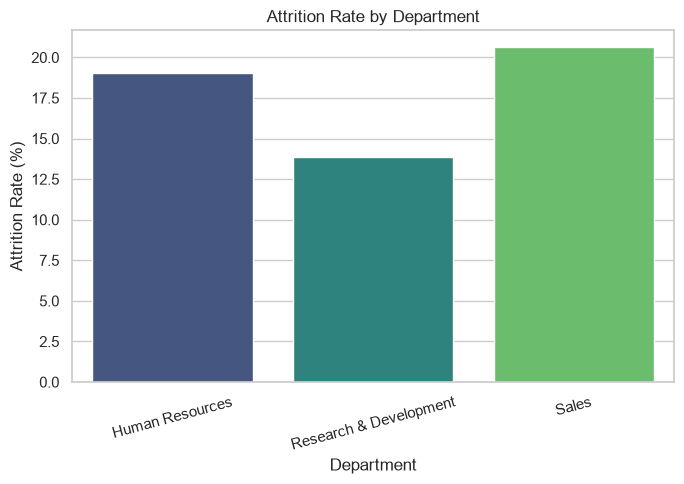

In [77]:
plt.figure(figsize=(7,5))

dept_attr = eda_df.groupby("Department")["Attrition"].apply(lambda x: (x=="Yes").mean()*100)

sns.barplot(
    x=dept_attr.index,
    y=dept_attr.values,
    hue=dept_attr.index,
    palette="viridis",
    legend=False
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

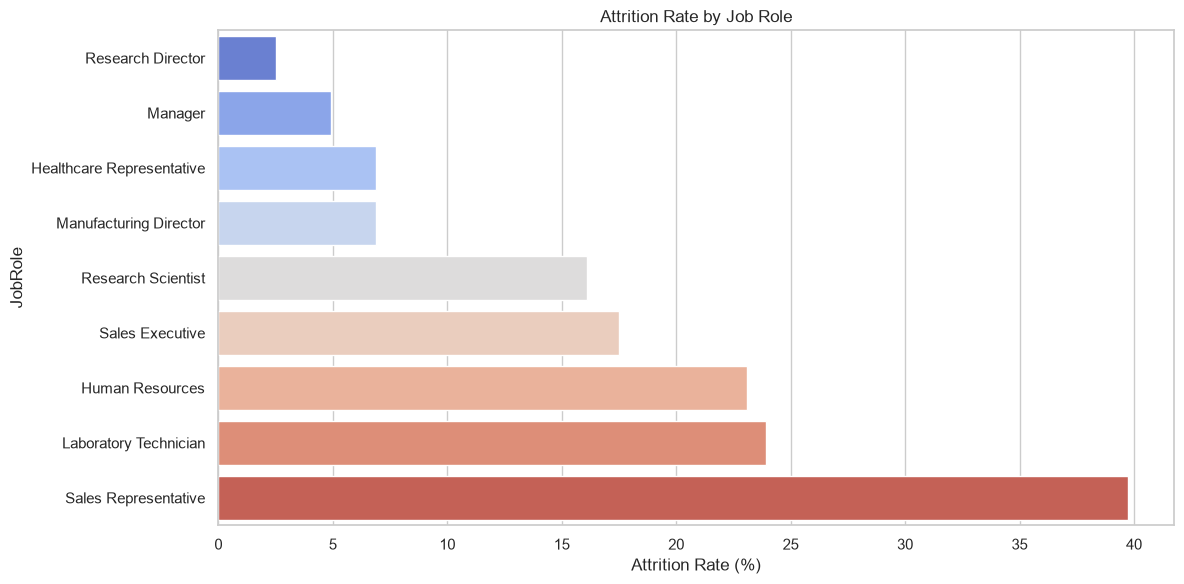

In [78]:
plt.figure(figsize=(12,6))

job_attr = eda_df.groupby("JobRole")["Attrition"].apply(lambda x: (x=="Yes").mean()*100).sort_values()

sns.barplot(
    x=job_attr.values,
    y=job_attr.index,
    hue=job_attr.index,
    palette="coolwarm",
    legend=False
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")

plt.tight_layout()
plt.savefig("charts/jobrole_attrition.png")
plt.show()

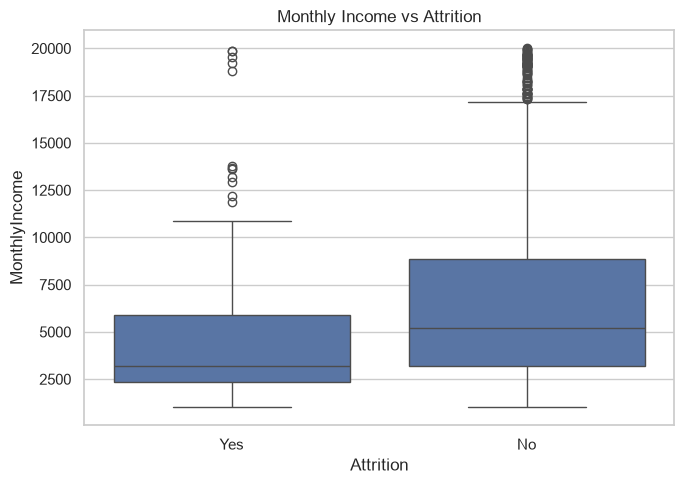

In [80]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=eda_df
)

plt.title("Monthly Income vs Attrition")

plt.tight_layout()
plt.savefig("charts/salary_attrition.png")
plt.show()

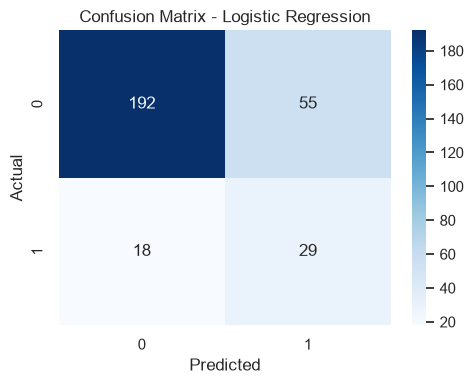

In [82]:
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("charts/confusion_matrix.png")
plt.show()

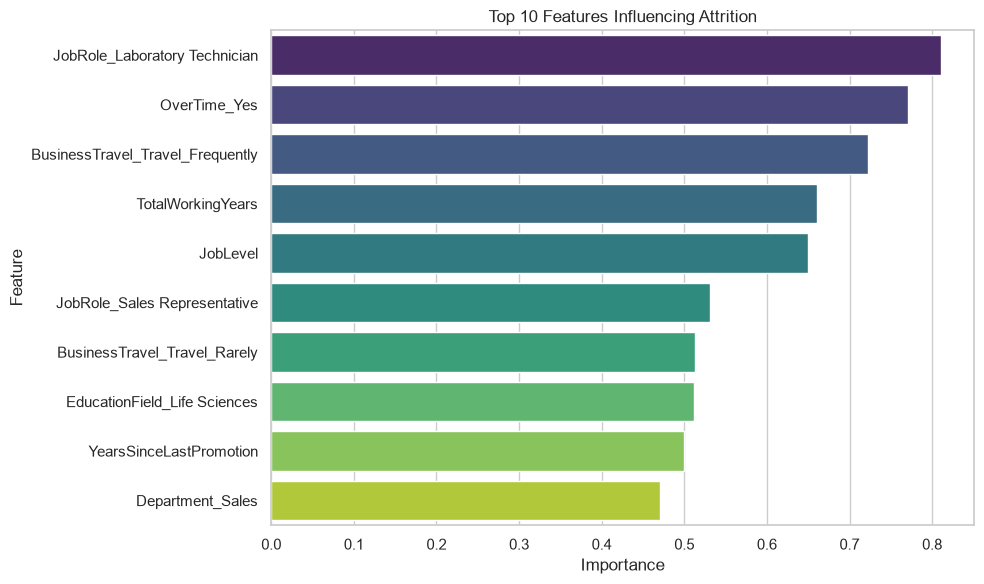

In [83]:
plt.figure(figsize=(10,6))

top10 = feature_importance.head(10)

sns.barplot(
    x=top10["Importance"],
    y=top10["Feature"],
    hue=top10["Feature"],
    palette="viridis",
    legend=False
)

plt.title("Top 10 Features Influencing Attrition")

plt.tight_layout()
plt.savefig("charts/top_features.png")
plt.show()

"""

Task 7: HR Insights & Business Recommendations
-------------------------------------------
Objective
---------
Convert data findings into business-level insights that
HR leaders can understand and act upon.

This section focuses on:
• Key drivers of attrition
• Departments at risk
• Salary impact
• Practical HR actions
"""
"""
1. Key Factors Influencing Attrition:
   - Overtime
   - Monthly income
   - Job role
   - Years at company

2. High-Risk Departments:
   - Sales and specific job roles show higher attrition rates.

3. Salary Impact:
   - Lower monthly income employees are more likely to leave,
     but salary alone is not the only factor.

4. Other Important Factors:
   - Work-life balance
   - Job satisfaction
   - Years of experience

5. HR Recommendations:
   - Reduce excessive overtime workload.
   - Improve work-life balance programs.
   - Introduce retention bonuses for high-risk roles.
   - Focus onboarding support for early-tenure employees.

6. Model Limitation:
   - The model is based on historical data and may not capture
     future behavioral changes or external market conditions.

"""

"""
Final Conclusion
----------------

This project successfully analyzed employee attrition data
and built machine learning models to predict employee turnover.

Logistic Regression was selected as the final model due to
its strong performance and interpretability.

The analysis revealed that attrition is influenced by multiple
factors including job role, income, overtime, and tenure.

These insights can help HR teams take proactive measures to
improve employee retention and reduce turnover costs.

"""